# Bayesian false-positive tests on real ERW data

Run the same statistical tests from the [ERW false-positive explorer](https://github.com/mati-carbon/erw-fpr-explorer) on a real paired soil-chemistry dataset, end-to-end. Choose one of three Mati datasets (or supply your own), pick an immobile and a mobile tracer, and the notebook produces:

| Test | Role | What it asks |
|---|---|---|
| Paired (or Welch) *t*-test on Δ*I* and Δ*X* | **Gate** | Is the observed change in concentration distinguishable from zero? |
| Statistical power (paired or Welch) | **Gate** | Is the test adequately powered to detect the observed effect? |
| Bayesian FPR via permutation inversion (p_r, p_rt) | **Gate** | Is the inferred CDR larger than what the soil-heterogeneity null produces? |
| Welch *t*-test (when data are paired) | Informational | What's the cost of treating pre/post as independent? |
| Posterior shrinkage on τ | Informational, with warning | How much weight does the data carry against the uniform prior on τ? |
| Joint posterior plot | Visual | The 2-D r–τ posterior, MAP, median, and τ-indistinguishable region |
| Null cloud scatter | Visual | The null distribution of (r_MAP, τ_MAP) with the observed point and r·τ iso-line |

### How this differs from the in-browser explorer

The explorer is co-optimized for in-browser calculation speed. This notebook is co-optimized for robustness:

|  | Explorer (HTML/JS) | This notebook |
|---|---|---|
| Likelihood for Δ*E* | Gaussian: σ = CV · mean(Δ) / √n | KDE over a bootstrap of (mean_post − mean_pre) |
| Posterior grid | 80 × 80 with cell-smearing variance correction | 160 × 160, no smearing |
| Null construction | Bivariate-Gaussian sampler with hardcoded ρ for paired vs unpaired | Permute the actual data: sign-flip per row (paired) or pool-and-reshuffle per element (unpaired) |

The notebook variants use the empirical Δ*E* distribution and a real permutation null, which is more representative than the Gaussian approximations the explorer uses. Numerical agreement on individual *p*-values is typically within ±0.005 to ±0.02 for the Mati datasets.


## Run me first

In [14]:
import sys, importlib, time
sys.path.insert(0, '.')
import utils; importlib.reload(utils)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jinja2
from scipy.stats import ttest_rel, ttest_ind, norm

# Section 1a — Dataset selection

## Bundled datasets

Three Mati ERW datasets are bundled. **Uncomment exactly one line below and run the cell.**

| Dataset | n | Region | Year |
|---|---|---|---|
| `nchg`  | 182 | North Chhattisgarh | 2024 (kharif) |
| `chg`   | 128 | Chhattisgarh | 2024 (kharif) |
| `seoni` | 171 | Seoni, Madhya Pradesh | 2024 (kharif) |

Basalt endmembers (ppm) are hardcoded for each dataset. These were derived from aggregated source-fingerprint measurements of the actual basalt dispatched to those deployments.

## Using your own dataset

To run your own data, prepare a CSV with **one row per observation** and these columns:

```
pair_index, {Immobile}_pre, {Immobile}_post, {Mobile}_pre, {Mobile}_post
```

where `{Immobile}` is the column-name prefix of your immobile tracer (typically `Ti`, but can be `Zr`, `Ni`, `Cu`, `V`, `Y`, etc.) and `{Mobile}` is your mobile tracer (typically `Ca` or `Mg`). All values in **ppm (mg / kg)**. You can include other element columns; they'll be ignored.

**Paired data:** each row is one location, sampled before and after rock application. Row *i*'s `_pre` and `_post` are physically paired.

**Unpaired data:** rows are observations from two independent populations (baseline vs reporting-period). Put your baseline observations under `_pre` and your reporting-period observations under `_post` in the same row positions; row pairing has no physical meaning. The two columns need not have the same number of non-null values.

**Add a basalt endmember dict.** Aggregate your dispatch-level basalt characterization to a single ppm value per element. Then add an entry to the `DATASETS` registry below:

```python
DATASETS['custom'] = {
    'path': Path('my_data.csv'),
    'label': 'My deployment',
    'basalt': {'Ti': 15000, 'Ca': 70000, 'Mg': 30000},  # YOUR values, in ppm
}
```
Then set `DATASET = 'custom'` in the cell below.

In [2]:
# Hardcoded basalt endmembers per dataset (ppm), pulled from the FPR explorer's
# preset values. Each dict must contain (at minimum) the immobile and mobile
# elements you plan to use.
DATASETS = {
    'nchg': {
        'path': Path('Mati_nchg.csv'),
        'label': 'Mati Carbon — NCHG 2024',
        'basalt': {'Ti': 17292, 'Ca': 68440, 'Mg': 29600},
    },
    'chg': {
        'path': Path('Mati_chg.csv'),
        'label': 'Mati Carbon — CHG 2024',
        'basalt': {'Ti': 14538, 'Ca': 70904, 'Mg': 37159},
    },
    'seoni': {
        'path': Path('Mati_seoni.csv'),
        'label': 'Mati Carbon — Seoni 2024',
        'basalt': {'Ti': 12513, 'Ca': 72660, 'Mg': 31730},
    },
}

# === PICK ONE ===
DATASET = 'nchg'
# DATASET = 'chg'
# DATASET = 'seoni'
# DATASET = 'custom'   # see Section 3 below

ds = DATASETS[DATASET]
print(f"Selected: {ds['label']}  (CSV: {ds['path']})")
print(f"Basalt endmembers (ppm): {ds['basalt']}")

Selected: Mati Carbon — NCHG 2024  (CSV: Mati_nchg.csv)
Basalt endmembers (ppm): {'Ti': 17292, 'Ca': 68440, 'Mg': 29600}


# Section 1b — Tracer choice and paired/unpaired toggle

Three user choices live in the next cell:

- **`IMMOBILE`** — element used as the immobile tracer. Default `'Ti'`. Must be a column prefix in your CSV (`{IMMOBILE}_pre`, `{IMMOBILE}_post`) and a key in your basalt dict.
- **`MOBILE`** — element used as the mobile tracer. The notebook runs the inversion for **one** mobile element at a time. To examine both Ca and Mg, run the notebook twice.
- **`PAIRED`** — `True` if rows in your CSV are physically paired (pre/post on the same location), `False` if they're two independent populations. The choice changes the null construction (sign-flip per row vs pool-and-reshuffle per element) and changes which *t*-test acts as the gate (paired vs Welch).

In [3]:
# === USER CHOICES ===
IMMOBILE = 'Ti'    # column-prefix in the CSV; must be a key in ds['basalt']
MOBILE   = 'Ca'    # column-prefix in the CSV; must be a key in ds['basalt']
PAIRED   = True    # True for sign-flip null; False for pool-and-reshuffle null

# ---- Load and validate ----
data = pd.read_csv(ds['path'])

# Check the required columns exist
required = [f'{IMMOBILE}_pre', f'{IMMOBILE}_post', f'{MOBILE}_pre', f'{MOBILE}_post']
missing = [c for c in required if c not in data.columns]
if missing:
    raise KeyError(f"CSV is missing required columns: {missing}\nAvailable: {data.columns.tolist()}")

# Check the basalt dict has both elements
for el in (IMMOBILE, MOBILE):
    if el not in ds['basalt']:
        raise KeyError(f"Basalt endmember for {el!r} not found in DATASETS[{DATASET!r}]['basalt']")

# Build the aggregated basalt endmember as a pd.Series (required form for utils.compute_posterior)
BASALT_ENDMEMBER = pd.Series(ds['basalt'])

# Rename {elem}_post to {elem}_post — utils.compute_posterior expects the _post suffix.
wide = data.rename(columns={f'{IMMOBILE}_post': f'{IMMOBILE}_post',
                            f'{MOBILE}_post':   f'{MOBILE}_post'})

# Decide which t-test acts as the forward-test gate
T_TEST_GATE = 'paired' if PAIRED else 'welch'

print(f"Immobile tracer (I): {IMMOBILE}    Cb_I = {BASALT_ENDMEMBER[IMMOBILE]:.0f} ppm")
print(f"Mobile tracer   (X): {MOBILE}    Cb_X = {BASALT_ENDMEMBER[MOBILE]:.0f} ppm")
print(f"Paired data: {PAIRED}    → t-test gate = {T_TEST_GATE}, "
      f"null = {'sign-flip per row' if PAIRED else 'pool-and-reshuffle per element'}")


Immobile tracer (I): Ti    Cb_I = 17292 ppm
Mobile tracer   (X): Ca    Cb_X = 68440 ppm
Paired data: False    → t-test gate = welch, null = pool-and-reshuffle per element


# Section 2 — Program setup

In [4]:
# ---- Grid + prior ----
# Extended r-prior; matches the explorer (which uses RMAX = 0.156).
RMAX = 0.156
R_RANGE = (0.0, RMAX)
TAU_RANGE = (0.0, 1.0)

# Grid is 160 × 160 here vs the explorer's 80 × 80 + cell-smearing correction.
# At 160² each posterior takes ~0.1–0.2 s, so a 1000-draw null finishes in ~20–30 s.
N_GRID = 160

# ---- Null / bootstrap counts ----
# Explorer uses 5,000 null draws of a parametric bivariate Gaussian (cheap).
# This notebook uses 1,000 draws because each draw runs a full inversion with
# a fresh per-element bootstrap and KDE. Empirically, p-values stabilize well
# below 1/N at 1,000 draws for the Mati datasets; bump to 5,000 if you want
# tighter resolution on borderline values.
N_NULL = 1000
B_OBSERVED = 10000   # bootstrap reps for observed ΔE KDE
B_NULL = 1000        # bootstrap reps inside each null draw

SEED = 12345

# ---- CDR-derived display only (not used in any test) ----
E_POT = 0.300         # t CO2 / t feedstock
DEPTH_CM = 6.0
BULK_DENSITY = 1.5    # g / cm3

# ---- Output directory ----
OUT_DIR = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)

# Section 3 — Data ingestion and summary

Mirrors the stat-block on the FPR explorer left-hand panel. Reports the sample size, pre-treatment soil mean (= Cs), basalt endmember (= Cb), and the bootstrap-free Δ*E* mean / std / CV for both tracers.

Two structural sanity checks are run, equivalent to the explorer's screens:
- **Negative-ΔE screen:** mean Δ*I* must be ≥ 0 (the mass-balance inversion's prediction is `ΔI_pred = r · (Ib − Is) ≥ 0`).
- **Basalt-soil contrast screen:** `Ib − Is` must be positive (otherwise no `r > 0` can produce the observed positive Δ*I*).

If either fails, the chosen immobile tracer is not usable; either change tracer or the dataset is incompatible with this framework.


In [5]:
def summarize_tracer(label, x_pre, x_post, Cb):
    '''Print one row of pre-treatment / endmember / Δ stats for a tracer.'''
    x_pre = np.asarray(x_pre, dtype=float)
    x_post = np.asarray(x_post, dtype=float)
    x_pre_c = x_pre[~np.isnan(x_pre)]
    x_post_c = x_post[~np.isnan(x_post)]
    Cs = x_pre_c.mean()
    if PAIRED:
        # Paired: difference per row
        d = x_post_c - x_pre_c[:len(x_post_c)]   # in our CSVs n_pre == n_post
        d_mean, d_std = d.mean(), d.std(ddof=1)
    else:
        # Unpaired: difference of population means; std via pooled SE × √n_eff
        d_mean = x_post_c.mean() - x_pre_c.mean()
        # For display only — use pooled std as a single-number summary
        d_std = float(np.sqrt(x_pre_c.var(ddof=1) + x_post_c.var(ddof=1)))
    cv = d_std / abs(d_mean) if d_mean != 0 else np.inf
    print(f"  {label} ({len(x_pre_c)} pre, {len(x_post_c)} post):  "
          f"Cs = {Cs:>9,.1f}    Cb = {Cb:>9,.0f}    "
          f"ΔE mean = {d_mean:>9,.1f}    ΔE std = {d_std:>9,.1f}    CV(ΔE) = {cv:.2f}")
    return dict(Cs=Cs, Cb=Cb, d_mean=d_mean, d_std=d_std, cv=cv,
                n_pre=len(x_pre_c), n_post=len(x_post_c))

print(f"=== {ds['label']} ===")
print(f"Rows in CSV: {len(data)}")
print()
print("Immobile and mobile tracer stats:")
stats_I = summarize_tracer(f'Δ{IMMOBILE} (immobile)',
                            wide[f'{IMMOBILE}_pre'], wide[f'{IMMOBILE}_post'],
                            BASALT_ENDMEMBER[IMMOBILE])
stats_X = summarize_tracer(f'Δ{MOBILE} (mobile)  ',
                            wide[f'{MOBILE}_pre'],   wide[f'{MOBILE}_post'],
                            BASALT_ENDMEMBER[MOBILE])

# ---- Structural screens ----
print()
print("Structural screens:")
problems = []
if stats_I['d_mean'] <= 0:
    problems.append(f"  ✗ FAIL: Δ{IMMOBILE} mean ({stats_I['d_mean']:.1f}) is not positive. "
                    "The mass-balance inversion predicts ΔI_pred ≥ 0; a negative observed value "
                    f"means {IMMOBILE} is not behaving as an immobile tracer in this dataset.")
else:
    print(f"  ✓ Δ{IMMOBILE} mean = {stats_I['d_mean']:.1f} ppm (positive — passes screen 1a)")

contrast_I = BASALT_ENDMEMBER[IMMOBILE] - stats_I['Cs']
if contrast_I <= 0:
    problems.append(f"  ✗ FAIL: Cb_I − Cs_I = {contrast_I:.1f} (basalt is poorer in {IMMOBILE} than soil). "
                    "The forward model cannot predict positive Δ{IMMOBILE} from r > 0; tracer is unusable.")
else:
    print(f"  ✓ Cb_{IMMOBILE} − Cs_{IMMOBILE} = {contrast_I:.0f} ppm (positive — passes screen 1b)")

contrast_X = BASALT_ENDMEMBER[MOBILE] - stats_X['Cs']
if contrast_X <= 0:
    problems.append(f"  ✗ FAIL: Cb_X − Cs_X = {contrast_X:.1f} (basalt is poorer in {MOBILE} than soil).")
else:
    print(f"  ✓ Cb_{MOBILE} − Cs_{MOBILE} = {contrast_X:.0f} ppm (positive — needed for mobile-tracer signal)")

if problems:
    print()
    print("STRUCTURAL ISSUES:")
    for p in problems:
        print(p)
    print()
    print("Inversion will proceed but results may be unreliable.")


=== Mati Carbon — NCHG 2024 ===
Rows in CSV: 182

Immobile and mobile tracer stats:
  ΔTi (immobile) (182 pre, 182 post):  Cs =   4,579.5    Cb =    17,292    ΔE mean =     743.4    ΔE std =   1,708.7    CV(ΔE) = 2.30
  ΔCa (mobile)   (182 pre, 182 post):  Cs =   3,333.3    Cb =    68,440    ΔE mean =   3,067.6    ΔE std =   5,050.4    CV(ΔE) = 1.65

Structural screens:
  ✓ ΔTi mean = 743.4 ppm (positive — passes screen 1a)
  ✓ Cb_Ti − Cs_Ti = 12712 ppm (positive — passes screen 1b)
  ✓ Cb_Ca − Cs_Ca = 65107 ppm (positive — needed for mobile-tracer signal)


# Section 4 — Forward statistical tests (gate + informational)

Two *t*-tests are run on each tracer:

- **Paired *t*-test** (`scipy.stats.ttest_rel(post, pre)`) — only valid when `PAIRED = True`.
- **Welch's *t*-test** (`scipy.stats.ttest_ind(post, pre, equal_var=False)`) — always valid; treats pre and post as independent populations.

When `PAIRED = True`, the paired *t*-test acts as the **gate** and Welch is informational. When `PAIRED = False`, Welch is the gate and the paired test is skipped.

**Statistical power** at α = 0.05 is computed via the same normal-approximation as the explorer (`Φ(ncp − z_crit) + Φ(−ncp − z_crit)`), with the noncentrality parameter from the empirical effect size.

**Status thresholds** (matching the explorer):
- *p*-value: ≤ 0.05 pass / ≤ 0.10 caution / else fail
- power: ≥ 0.80 pass / ≥ 0.50 caution / else fail


In [6]:
Z_CRIT = norm.ppf(0.975)  # ≈ 1.959964 — two-sided α = 0.05

def power_normal_approx(ncp):
    '''Two-sided power under a normal approximation, given noncentrality parameter.'''
    return float(norm.cdf(ncp - Z_CRIT) + norm.cdf(-ncp - Z_CRIT))

def n_for_80_power_paired(dz):
    '''Sample size needed for 80% power in a paired t-test, given Cohen's dz.'''
    if dz <= 0:
        return float('inf')
    z80 = norm.ppf(0.80)
    return int(np.ceil((Z_CRIT + z80) ** 2 / (dz ** 2)))

def run_t_tests(label, x_pre, x_post):
    x_pre = np.asarray(x_pre, dtype=float); x_pre = x_pre[~np.isnan(x_pre)]
    x_post = np.asarray(x_post, dtype=float); x_post = x_post[~np.isnan(x_post)]
    n_pre, n_post = len(x_pre), len(x_post)

    out = {'label': label, 'n_pre': n_pre, 'n_post': n_post}

    # Welch (always valid; used as gate when not paired)
    welch = ttest_ind(x_post, x_pre, equal_var=False, nan_policy='omit')
    out['p_welch'] = float(welch.pvalue)
    # Welch effect size + power (Cohen's d using pooled-σ approximation)
    var_p = ((n_pre - 1) * x_pre.var(ddof=1) + (n_post - 1) * x_post.var(ddof=1)) / (n_pre + n_post - 2)
    d_welch = (x_post.mean() - x_pre.mean()) / np.sqrt(var_p)
    out['d_welch'] = d_welch
    # noncentrality parameter for two independent groups with sizes n_pre, n_post
    ncp_welch = d_welch * np.sqrt(n_pre * n_post / (n_pre + n_post))
    out['power_welch'] = power_normal_approx(ncp_welch)

    # Paired (only valid when rows are paired and n_pre == n_post)
    if PAIRED and n_pre == n_post:
        paired = ttest_rel(x_post, x_pre, nan_policy='omit')
        out['p_paired'] = float(paired.pvalue)
        d = x_post - x_pre
        dz = d.mean() / d.std(ddof=1)
        out['dz_paired'] = dz
        out['power_paired'] = power_normal_approx(dz * np.sqrt(n_pre))
        out['n80_paired'] = n_for_80_power_paired(dz)
    else:
        out['p_paired'] = None
        out['power_paired'] = None
        out['n80_paired'] = None
    return out

# ---- Run the t-tests ----
tt_I = run_t_tests(f'Δ{IMMOBILE}', wide[f'{IMMOBILE}_pre'], wide[f'{IMMOBILE}_post'])
tt_X = run_t_tests(f'Δ{MOBILE}',   wide[f'{MOBILE}_pre'],   wide[f'{MOBILE}_post'])

# ---- Print ----
def fmt_p(p):
    if p is None: return '   n/a'
    if p < 1e-3:  return f'{p:.1e}'
    if p < 1e-2:  return f'{p:.4f}'
    return f'{p:.3f}'

print(f"=== t-tests (paired = gate when PAIRED, else Welch = gate) ===")
print(f"  {'tracer':10s}   {'p (paired)':>12s}   {'p (Welch)':>12s}   "
      f"{'power (paired)':>16s}   {'power (Welch)':>16s}   {'n for 80% (paired)':>20s}")
for tt in [tt_I, tt_X]:
    pp = fmt_p(tt['p_paired']); pw = fmt_p(tt['p_welch'])
    pow_p = f"{tt['power_paired']*100:>14.1f}%" if tt['power_paired'] is not None else '            n/a'
    pow_w = f"{tt['power_welch']*100:>14.1f}%"
    n80   = f"{tt['n80_paired']:>20d}" if (tt['n80_paired'] is not None and np.isfinite(tt['n80_paired'])) else '                 n/a'
    print(f"  {tt['label']:10s}   {pp:>12s}   {pw:>12s}   {pow_p:>16s}   {pow_w:>16s}   {n80:>20s}")

# Store statuses for the summary table
def status_p(p):
    if p is None: return 'n/a'
    if p <= 0.05: return 'pass'
    if p <= 0.10: return 'caution'
    return 'fail'
def status_power(pw):
    if pw is None: return 'n/a'
    if pw >= 0.80: return 'pass'
    if pw >= 0.50: return 'caution'
    return 'fail'

forward_results = {
    'I': tt_I, 'X': tt_X,
    't_gate_I': tt_I['p_paired'] if PAIRED else tt_I['p_welch'],
    't_gate_X': tt_X['p_paired'] if PAIRED else tt_X['p_welch'],
    'power_gate_I': tt_I['power_paired'] if PAIRED else tt_I['power_welch'],
    'power_gate_X': tt_X['power_paired'] if PAIRED else tt_X['power_welch'],
}


=== t-tests (paired = gate when PAIRED, else Welch = gate) ===
  tracer         p (paired)      p (Welch)     power (paired)      power (Welch)     n for 80% (paired)
  ΔTi                   n/a        1.0e-08                n/a             100.0%                    n/a
  ΔCa                   n/a        2.0e-14                n/a             100.0%                    n/a


# Section 5 — Bayesian posterior inversion (observed data)

Run the joint inversion `p(r, τ | Δ*I*, Δ*X*)` on a 160 × 160 grid. Each axis covers:

- **r ∈ [0, 0.156]** — rock application rate (mass fraction of rock added to soil)
- **τ ∈ [0, 1]** — weathering extent (fraction of added rock dissolved)

Likelihood = KDE over a bootstrap of mean(Δ*E*) for both tracers. Forward model uses the soil-cation-dilution form
`ΔX_pred = r · ((1 − τ) · Cb_X − Cs_X)` (same as the explorer; differs from the traditional TiCAT `r · (1 − τ) · (Cb − Cs)`).

This runs **once** for the chosen `(IMMOBILE, MOBILE)`.

**Three summary statistics:**

- **Joint MAP** `(r_MAP, τ_MAP)`: location of the joint posterior's peak.
- **Marginal medians and CIs**: integrate one axis out, take percentiles of the resulting 1-D distribution.
- **E[r·τ]**: posterior expectation of the product, computed by direct integration. The explorer's `p_rt` test uses this (not `r_MAP · τ_MAP`) because it properly accounts for the joint posterior's ridge correlation.


In [7]:
# ---- Bootstrap ΔE for both tracers ----
bootstraps = {}
for elem in (IMMOBILE, MOBILE):
    pre = wide[f'{elem}_pre'].to_numpy()
    post = wide[f'{elem}_post'].to_numpy()
    bootstraps[elem] = utils.bootstrap_delta_E(pre, post, B=B_OBSERVED, seed=SEED)
    d = bootstraps[elem]['delta_boot']
    print(f"  {elem} ΔE bootstrap: mean = {d.mean():.1f}, std = {d.std():.1f} (B = {B_OBSERVED})")

# ---- Run the joint inversion ----
t0 = time.time()
r_grid, tau_grid, post = utils.compute_posterior(
    wide, bootstraps,
    immobile=IMMOBILE,
    mobile=(MOBILE,),                # single-element tuple — one mobile at a time
    r_range=R_RANGE, tau_range=TAU_RANGE,
    n_grid=N_GRID,
    aggregated_basalt=BASALT_ENDMEMBER,
)
elapsed = time.time() - t0

# ---- Summarize ----
p_r, p_tau = utils.marginalize(r_grid, tau_grid, post)
r_summ = utils.summarize_marginal(r_grid, p_r)
tau_summ = utils.summarize_marginal(tau_grid, p_tau)
r_MAP_obs, tau_MAP_obs = utils.joint_map(r_grid, tau_grid, post)

# E[r·τ] — joint posterior expectation of the product. This is the explorer's
# T3 statistic. It differs from r_MAP · τ_MAP whenever the posterior is
# anisotropic (a ridge along constant r·τ contributes mass that the MAP product
# misses).
R_mesh, T_mesh = np.meshgrid(r_grid, tau_grid, indexing='ij')
rt_mean_obs = float(np.trapezoid(np.trapezoid(post * R_mesh * T_mesh, x=tau_grid, axis=1), x=r_grid))

# CDR — display only
A_obs = r_MAP_obs * BULK_DENSITY * DEPTH_CM * 100  # t feedstock / ha
CDR_at_MAP = E_POT * A_obs * tau_MAP_obs                    # t CO2 / ha
CDR_E_rt   = E_POT * BULK_DENSITY * DEPTH_CM * 100 * rt_mean_obs  # uses E[r·τ]

print()
print(f"Posterior computed in {elapsed:.2f}s (grid {post.shape}).")
print()
print(f"Joint MAP:        r = {r_MAP_obs:.4f}    τ = {tau_MAP_obs:.3f}    r·τ = {r_MAP_obs*tau_MAP_obs:.5f}")
print(f"Marginal median:  r = {r_summ['median']:.4f}    τ = {tau_summ['median']:.3f}")
print(f"r 68% CI:  [{r_summ['ci68_lo']:.4f}, {r_summ['ci68_hi']:.4f}]    "
      f"r 95% CI:  [{r_summ['ci95_lo']:.4f}, {r_summ['ci95_hi']:.4f}]")
print(f"τ 68% CI:  [{tau_summ['ci68_lo']:.3f}, {tau_summ['ci68_hi']:.3f}]    "
      f"τ 95% CI:  [{tau_summ['ci95_lo']:.3f}, {tau_summ['ci95_hi']:.3f}]")
print()
print(f"E[r·τ]   = {rt_mean_obs:.5f}   (used as the T3 statistic against the null)")
print()
print(f"Initial CDR display (E_POT = {E_POT}, depth = {DEPTH_CM} cm, bulk density = {BULK_DENSITY}):")
print(f"  at joint MAP:  {CDR_at_MAP:.3f}  t CO2 / ha")
print(f"  via E[r·τ]:    {CDR_E_rt:.3f}  t CO2 / ha")


  Ti ΔE bootstrap: mean = 743.8, std = 127.3 (B = 10000)
  Ca ΔE bootstrap: mean = 3069.6, std = 374.1 (B = 10000)

Posterior computed in 0.29s (grid (160, 160)).

Joint MAP:        r = 0.0589    τ = 0.182    r·τ = 0.01074
Marginal median:  r = 0.0588    τ = 0.200
r 68% CI:  [0.0508, 0.0679]    r 95% CI:  [0.0444, 0.0776]
τ 68% CI:  [0.076, 0.326]    τ 95% CI:  [0.009, 0.433]

E[r·τ]   = 0.01312   (used as the T3 statistic against the null)

Initial CDR display (E_POT = 0.3, depth = 6.0 cm, bulk density = 1.5):
  at joint MAP:  2.899  t CO2 / ha
  via E[r·τ]:    3.543  t CO2 / ha


# Section 6 — Bayesian FPR via permutation null

Generate **N = 1000** null draws and re-run the inversion for each. Two null constructions, selected by `PAIRED`:

- **`PAIRED = True`** → **paired sign-flip null.** For each draw, sample a sign vector `s ∈ {−1, +1}^n` (one element per row, shared across tracers within a draw to preserve multivariate correlation). When `s_i = −1`, swap row *i*'s `_pre` and `_post` labels. Then rebootstrap each tracer's Δ*E* from the (mostly relabeled) data and re-invert.
- **`PAIRED = False`** → **population-level permutation null.** For each tracer, pool the baseline and reporting-period values into one bag, reshuffle, split back into pre/post of the original sizes. Rebootstrap Δ*E* and re-invert.

Both nulls answer the same question: *if there were no rock weathering signal (only soil heterogeneity / measurement noise), how often would we see an inferred r·τ as large as observed?*

**Two test statistics** (both follow the explorer):
- **p_r** = fraction of null draws where `r_median_null ≥ r_median_observed`
- **p_rt** = fraction of null draws where `E[r·τ]_null ≥ E[r·τ]_observed`

**Decision rule:** pass iff `p_r ≤ 0.05 AND p_rt ≤ 0.05`. Caution if exactly one of the two is in (0.05, 0.10]. Fail otherwise.


In [8]:
def run_null_loop(N=N_NULL, B=B_NULL, n_grid=N_GRID, seed=SEED, verbose=True):
    '''One unified loop. The PAIRED flag determines null construction.'''
    rng = np.random.default_rng(seed)
    n_samples = len(wide)
    out = {'r_med': [], 'tau_med': [], 'r_MAP': [], 'tau_MAP': [], 'rt_mean': []}
    t0 = time.time()
    skipped = 0
    for j in range(N):
        bootstraps_null = {}
        null_pre = {}   # the (relabeled) "pre" values, fed to compute_posterior as Cs

        if PAIRED:
            # Sign-flip per row, shared sign vector across both tracers
            s = rng.choice([-1, 1], size=n_samples)
            for el in (IMMOBILE, MOBILE):
                xp = wide[f'{el}_pre'].to_numpy(dtype=float)
                xe = wide[f'{el}_post'].to_numpy(dtype=float)
                xp_null = np.where(s > 0, xp, xe)
                xe_null = np.where(s > 0, xe, xp)
                boot = utils.bootstrap_delta_E(xp_null, xe_null, B=B)
                if boot is None:
                    continue
                bootstraps_null[el] = boot
                null_pre[f'{el}_pre'] = xp_null
        else:
            # Pool-and-reshuffle per element (independent across tracers)
            for el in (IMMOBILE, MOBILE):
                xp = wide[f'{el}_pre'].to_numpy(dtype=float)
                xe = wide[f'{el}_post'].to_numpy(dtype=float)
                xp_c = xp[~np.isnan(xp)]
                xe_c = xe[~np.isnan(xe)]
                pooled = np.concatenate([xp_c, xe_c])
                n_pre = len(xp_c)
                perm = rng.permutation(pooled)
                xp_null, xe_null = perm[:n_pre], perm[n_pre:]
                boot = utils.bootstrap_delta_E(xp_null, xe_null, B=B)
                if boot is None:
                    continue
                bootstraps_null[el] = boot
                null_pre[f'{el}_pre'] = pd.Series(xp_null)

        if IMMOBILE not in bootstraps_null or MOBILE not in bootstraps_null:
            skipped += 1
            continue

        null_df = pd.DataFrame(null_pre)
        rg, tg, pg = utils.compute_posterior(
            null_df, bootstraps_null,
            immobile=IMMOBILE, mobile=(MOBILE,),
            r_range=R_RANGE, tau_range=TAU_RANGE,
            n_grid=n_grid, aggregated_basalt=BASALT_ENDMEMBER,
        )
        # Summaries
        prn, ptn = utils.marginalize(rg, tg, pg)
        out['r_med'].append(utils.summarize_marginal(rg, prn)['median'])
        out['tau_med'].append(utils.summarize_marginal(tg, ptn)['median'])
        rMAP, tauMAP = utils.joint_map(rg, tg, pg)
        out['r_MAP'].append(rMAP); out['tau_MAP'].append(tauMAP)
        Rg, Tg = np.meshgrid(rg, tg, indexing='ij')
        out['rt_mean'].append(float(np.trapezoid(np.trapezoid(pg * Rg * Tg, x=tg, axis=1), x=rg)))

        if verbose and (j + 1) % max(1, N // 5) == 0:
            print(f"  null {j+1}/{N} ({time.time()-t0:.0f}s elapsed)")

    if verbose:
        print(f"Null loop finished in {time.time()-t0:.0f}s "
              f"({skipped} draws skipped due to bootstrap/inversion failures)")
    return {k: np.asarray(v) for k, v in out.items()}

# ---- Run it ----
null_label = 'paired sign-flip' if PAIRED else 'pool-and-reshuffle'
print(f"Running {null_label} null, N = {N_NULL}, B = {B_NULL} per draw...")
null = run_null_loop()

# ---- p-values ----
p_r_bayes  = float(np.mean(null['r_med']   >= r_summ['median']))
p_rt_bayes = float(np.mean(null['rt_mean'] >= rt_mean_obs))

print()
print(f"=== Bayesian FPR results ===")
print(f"  p_r   = {p_r_bayes:.4f}   (observed r_median = {r_summ['median']:.4f}, "
      f"null r_median range = [{null['r_med'].min():.4f}, {null['r_med'].max():.4f}])")
print(f"  p_rt  = {p_rt_bayes:.4f}   (observed E[r·τ]  = {rt_mean_obs:.5f}, "
      f"null range = [{null['rt_mean'].min():.5f}, {null['rt_mean'].max():.5f}])")

# Decision rule status for the summary table
def fpr_status(p_r, p_rt):
    if p_r <= 0.05 and p_rt <= 0.05:
        return 'pass'
    elif (p_r <= 0.05 and 0.05 < p_rt <= 0.10) or (p_rt <= 0.05 and 0.05 < p_r <= 0.10):
        return 'caution'
    else:
        return 'fail'

print(f"  Decision rule (p_r ≤ 0.05 AND p_rt ≤ 0.05):  "
      f"{fpr_status(p_r_bayes, p_rt_bayes).upper()}")


Running pool-and-reshuffle null, N = 1000, B = 1000 per draw...
  null 200/1000 (9s elapsed)
  null 400/1000 (18s elapsed)
  null 600/1000 (27s elapsed)
  null 800/1000 (35s elapsed)
  null 1000/1000 (44s elapsed)
Null loop finished in 44s (0 draws skipped due to bootstrap/inversion failures)

=== Bayesian FPR results ===
  p_r   = 0.0000   (observed r_median = 0.0588, null r_median range = [0.0006, 0.0273])
  p_rt  = 0.0330   (observed E[r·τ]  = 0.01312, null range = [0.00089, 0.02432])
  Decision rule (p_r ≤ 0.05 AND p_rt ≤ 0.05):  PASS


# Section 7 — Posterior shrinkage on r and τ (informational)

Shrinkage measures how much variance the data has eliminated relative to the (uniform) prior:

```
shrinkage = 1 − Var(posterior marginal) / Var(prior marginal)
```

Uniform priors give `Var(r_prior) = RMAX² / 12` and `Var(τ_prior) = 1/12`. Interpretation:

- **shrinkage ≈ 1** — posterior is a tight peak; data fully determines the parameter.
- **shrinkage ≈ 0** — posterior matches prior; the data added nothing.

The equivalent **data : prior odds** is `shrinkage / (1 − shrinkage)`. A value of 4:1 (shrinkage = 0.80) is conventionally the threshold for "the data is driving the posterior."

τ is the parameter the framework most often fails to determine (because τ is unidentifiable when r is small). A shrinkage on τ below 0.80 (< 4:1 data:prior odds) triggers a **warning** below.


In [9]:
# Posterior variances by direct integration of the marginals
mean_r   = float(np.trapezoid(p_r   * r_grid,   x=r_grid))
mean_tau = float(np.trapezoid(p_tau * tau_grid, x=tau_grid))
var_r_post   = float(np.trapezoid(p_r   * (r_grid   - mean_r)**2,   x=r_grid))
var_tau_post = float(np.trapezoid(p_tau * (tau_grid - mean_tau)**2, x=tau_grid))

var_r_prior   = RMAX**2 / 12       # uniform on [0, RMAX]
var_tau_prior = 1.0 / 12           # uniform on [0, 1]

shrink_r   = 1 - var_r_post   / var_r_prior
shrink_tau = 1 - var_tau_post / var_tau_prior

def odds_str(s):
    s_clamped = max(0.0, min(0.9999, s))
    odds = s_clamped / (1 - s_clamped)
    return '∞:1' if not np.isfinite(odds) else f'{odds:.2f}:1'

def status_shrink(s):
    if s >= 0.80:   return 'pass'
    if s >= 0.6667: return 'caution'
    return 'fail'

print(f"=== Posterior shrinkage ===")
print(f"  shrinkage on r:   {shrink_r:.3f}    (data : prior odds = {odds_str(shrink_r)})")
print(f"  shrinkage on τ:   {shrink_tau:.3f}    (data : prior odds = {odds_str(shrink_tau)})")
print()
print(f"Status thresholds: ≥ 0.80 pass  /  ≥ 0.6667 caution  /  else fail")
print(f"  → status on τ: {status_shrink(shrink_tau).upper()}")

if shrink_tau < 0.80:
    print()
    print(f"  ⚠  WARNING: posterior on τ is prior-driven (data : prior odds only {odds_str(shrink_tau)}).")
    print(f"     τ-marginal outputs should be treated with caution. The credit-relevant joint")
    print(f"     statistic E[r·τ] may still be well-determined even when τ is not — check the")
    print(f"     Bayesian FPR result (p_rt above) and the joint-posterior plot below.")


=== Posterior shrinkage ===
  shrinkage on r:   0.964    (data : prior odds = 26.64:1)
  shrinkage on τ:   0.842    (data : prior odds = 5.31:1)

Status thresholds: ≥ 0.80 pass  /  ≥ 0.6667 caution  /  else fail
  → status on τ: PASS


# Section 8 — Joint posterior plot

The Jordan-style joint posterior with MAP (orange square) and marginal-median (blue circle) markers, 68% and 95% HPD contours, and the cross-hatched τ-indistinguishable region where Δ*X* predicted from `(r, τ)` is within noise of zero.

The τ-indistinguishable threshold uses
`τ_crit(r) = 1 − (Cs_X + z_crit · σ_X / r) / Cb_X`
with σ_X = std of the Δ*X* bootstrap distribution (different from the explorer, which uses σ_X = CV · mean / √n — but the bootstrap std is the consistent choice given the KDE-of-bootstrap likelihood).


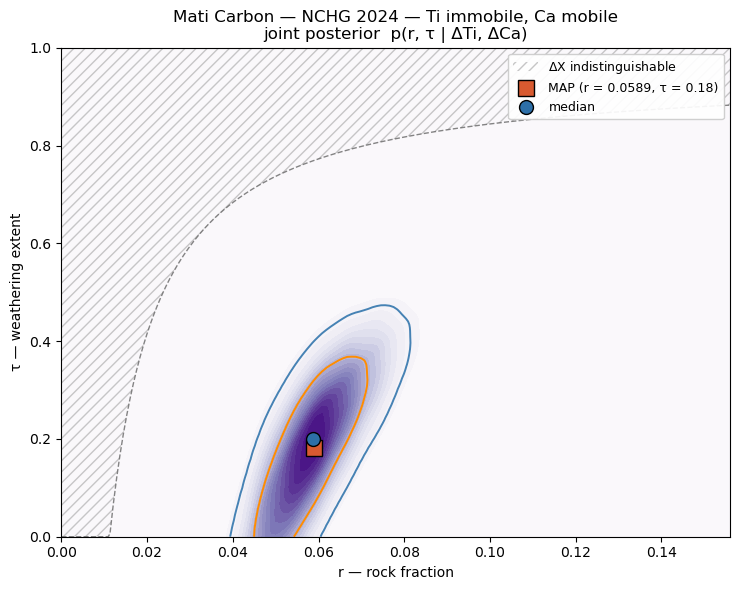

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 6))
Rm, Tm = np.meshgrid(r_grid, tau_grid, indexing='ij')

# Filled posterior
cf = ax.contourf(Rm, Tm, post, levels=24, cmap='Purples')

# 68 and 95 % HPD contours
ps_sorted = np.sort(post.ravel())[::-1]
cum = np.cumsum(ps_sorted); cum /= cum[-1]
lvl_68 = ps_sorted[np.searchsorted(cum, 0.68)]
lvl_95 = ps_sorted[np.searchsorted(cum, 0.95)]
ax.contour(Rm, Tm, post, levels=[lvl_95, lvl_68],
           colors=['steelblue', 'darkorange'], linewidths=[1.4, 1.4])

# τ-indistinguishable region. σ_X = bootstrap std of ΔX (consistent with the
# KDE-of-bootstrap likelihood we actually used in the inversion).
sigma_X = float(bootstraps[MOBILE]['delta_boot'].std())
Cs_X = stats_X['Cs']
Cb_X = BASALT_ENDMEMBER[MOBILE]
rr = np.linspace(r_grid[0] + 1e-6, r_grid[-1], 400)
tau_crit = 1 - (Cs_X + Z_CRIT * sigma_X / rr) / Cb_X
tau_crit_clipped = np.clip(tau_crit, 0, 1)
ax.fill_between(rr, tau_crit_clipped, 1.0, hatch='///', facecolor='none',
                edgecolor='#888', linewidth=0.0, alpha=0.45,
                label='$\Delta$X indistinguishable')
ax.plot(rr, tau_crit_clipped, '--', color='#666', linewidth=1.0, alpha=0.8)

# MAP and median markers
ax.plot(r_MAP_obs, tau_MAP_obs, 's', color='#D85A30', markeredgecolor='black',
        markersize=11, label=f'MAP (r = {r_MAP_obs:.4f}, τ = {tau_MAP_obs:.2f})', zorder=5)
ax.plot(r_summ['median'], tau_summ['median'], 'o', color='#2D6FA8', markeredgecolor='black',
        markersize=10, label='median', zorder=5)

ax.set_xlim(R_RANGE); ax.set_ylim(TAU_RANGE)
ax.set_xlabel('r — rock fraction')
ax.set_ylabel('τ — weathering extent')
ax.set_title(f"{ds['label']} — {IMMOBILE} immobile, {MOBILE} mobile\n"
             f"joint posterior  p(r, τ | Δ{IMMOBILE}, Δ{MOBILE})")
ax.legend(loc='upper right', fontsize=9, framealpha=0.92)
fig.tight_layout()
fig.savefig(OUT_DIR / f'joint_posterior_{DATASET}_{IMMOBILE}_{MOBILE}.png', dpi=140, bbox_inches='tight')
plt.show()


# Section 9 — τ marginal outputs

The τ-only summary, including the 95% HPD overlap check: if the joint posterior's 95% high-density region extends into the τ-indistinguishable zone, the τ estimate is not robust (the data alone cannot rule out values where the mobile-tracer constraint is degenerate).


In [11]:
# Test whether any cell inside the 95% HPD region falls into the τ-indistinguishable zone.
# Mirrors `posteriorCrossesLine` in the explorer.
sigma_X = float(bootstraps[MOBILE]['delta_boot'].std())
Cs_X = stats_X['Cs']; Cb_X = BASALT_ENDMEMBER[MOBILE]

crosses = False
in_hpd95 = post >= lvl_95
for i, r in enumerate(r_grid):
    if r <= 0: continue
    tau_cr = 1 - (Cs_X + Z_CRIT * sigma_X / r) / Cb_X
    tau_cr_clipped = max(0.0, min(1.0, tau_cr))
    above_idx = np.searchsorted(tau_grid, tau_cr_clipped)
    if in_hpd95[i, above_idx:].any():
        crosses = True
        break

print(f"=== τ marginal ===")
print(f"  τ_MAP        = {tau_MAP_obs:.3f}    (joint MAP)")
print(f"  τ_median     = {tau_summ['median']:.3f}")
print(f"  τ_mean       = {mean_tau:.3f}")
print(f"  τ 68 % CI    = [{tau_summ['ci68_lo']:.3f}, {tau_summ['ci68_hi']:.3f}]")
print(f"  τ 95 % CI    = [{tau_summ['ci95_lo']:.3f}, {tau_summ['ci95_hi']:.3f}]")
print()
print(f"  95 % HPD overlaps τ-indistinguishable zone:  {'YES — τ not robust' if crosses else 'no'}")


=== τ marginal ===
  τ_MAP        = 0.182    (joint MAP)
  τ_median     = 0.200
  τ_mean       = 0.208
  τ 68 % CI    = [0.076, 0.326]
  τ 95 % CI    = [0.009, 0.433]

  95 % HPD overlaps τ-indistinguishable zone:  no


# Section 10 — Final summary table

Color-coded summary of every gate and informational test. The overall verdict is the worst-of among the three gates (*t*-test, power, Bayesian FPR). Informational rows (Welch, shrinkage) do not drive the verdict but flag follow-up considerations.

| Color | Meaning |
|---|---|
| Green | PASS — meets credit-grade threshold |
| Yellow | CAUTION — passes a weaker threshold; worth a second look |
| Red | FAIL — does not meet threshold |
| Grey | INFO — not gating |


In [12]:
# ---- Build the table ----
rows = []

# Forward t-test gate rows (one per tracer)
for tt, role in [(tt_I, f'Δ{IMMOBILE}'), (tt_X, f'Δ{MOBILE}')]:
    p_gate = tt['p_paired'] if PAIRED else tt['p_welch']
    rows.append({
        'Test':      f"{'paired' if PAIRED else 'Welch'} t-test on {role}",
        'Type':      'Gate',
        'Value':     f"p = {fmt_p(p_gate)}",
        'Threshold': 'p ≤ 0.05',
        'Status':    status_p(p_gate).upper() if p_gate is not None else 'N/A',
    })

# Power gate rows
for tt, role in [(tt_I, f'Δ{IMMOBILE}'), (tt_X, f'Δ{MOBILE}')]:
    pw_gate = tt['power_paired'] if PAIRED else tt['power_welch']
    rows.append({
        'Test':      f"statistical power on {role}",
        'Type':      'Gate',
        'Value':     f"{pw_gate*100:.1f}%" if pw_gate is not None else 'n/a',
        'Threshold': 'power ≥ 80%',
        'Status':    status_power(pw_gate).upper() if pw_gate is not None else 'N/A',
    })

# Bayesian FPR gate (two p-values shown, single combined status)
fpr_st = fpr_status(p_r_bayes, p_rt_bayes)
rows.append({
    'Test':      'Bayesian FPR — p_r',
    'Type':      'Gate',
    'Value':     f"p_r = {fmt_p(p_r_bayes)}",
    'Threshold': 'p_r ≤ 0.05',
    'Status':    status_p(p_r_bayes).upper(),
})
rows.append({
    'Test':      'Bayesian FPR — p_rt (uses E[r·τ])',
    'Type':      'Gate',
    'Value':     f"p_rt = {fmt_p(p_rt_bayes)}",
    'Threshold': 'p_rt ≤ 0.05',
    'Status':    status_p(p_rt_bayes).upper(),
})

# Informational rows
# Welch (only informational when data are paired; when not paired it IS the gate, already shown above)
if PAIRED:
    for tt, role in [(tt_I, f'Δ{IMMOBILE}'), (tt_X, f'Δ{MOBILE}')]:
        rows.append({
            'Test':      f"Welch t-test on {role}",
            'Type':      'Info',
            'Value':     f"p = {fmt_p(tt['p_welch'])}",
            'Threshold': '—',
            'Status':    'INFO',
        })

# Posterior shrinkage on τ
shrink_st = status_shrink(shrink_tau)
rows.append({
    'Test':      'posterior shrinkage on τ',
    'Type':      'Info',
    'Value':     f"{shrink_tau:.3f}  ({odds_str(shrink_tau)} data:prior)",
    'Threshold': '≥ 0.80 = data drives',
    'Status':    f'INFO — {shrink_st.upper()}',
})

# Overall verdict
def combine(*statuses):
    statuses = [s for s in statuses if s != 'n/a']
    if any(s == 'fail' for s in statuses):    return 'fail'
    if any(s == 'caution' for s in statuses): return 'caution'
    return 'pass'

# Combine all gate row statuses (extract lowercase status from the rows we just built)
gate_statuses = [r['Status'].lower() for r in rows if r['Type'] == 'Gate' and r['Status'] != 'N/A']
overall = combine(*gate_statuses)
rows.append({
    'Test':      'OVERALL VERDICT  (worst of the three gates)',
    'Type':      '—',
    'Value':     '—',
    'Threshold': '—',
    'Status':    overall.upper(),
})

table_df = pd.DataFrame(rows, columns=['Test', 'Type', 'Value', 'Threshold', 'Status'])

# ---- Color-code via pandas Styler ----
COLORS = {
    'PASS':    ('#E8F4E8', '#3B6D11'),
    'CAUTION': ('#FFF4D6', '#7A5400'),
    'FAIL':    ('#F8E0E0', '#A32D2D'),
    'INFO':    ('#EFEFEF', '#444444'),
    'N/A':     ('#FFFFFF', '#888888'),
}
def color_row(row):
    s = row['Status']
    # The shrinkage row uses 'INFO — XXX' — pull the secondary status for coloring
    if s.startswith('INFO'):
        secondary = s.split('—')[-1].strip() if '—' in s else 'INFO'
        bg, fg = COLORS.get(secondary, COLORS['INFO'])
        # Use a muted version: keep info-grey background but tint with secondary
        bg = COLORS[secondary][0] if secondary in COLORS else COLORS['INFO'][0]
        fg = '#444'
    elif s in COLORS:
        bg, fg = COLORS[s]
    else:
        bg, fg = '#FFFFFF', '#000'
    # Last row (OVERALL VERDICT) gets bolder formatting
    weight = 'bold' if row['Test'].startswith('OVERALL') else 'normal'
    return [f'background-color: {bg}; color: {fg}; font-weight: {weight}'] * len(row)

styled = (table_df.style
          .hide(axis='index')
          .apply(color_row, axis=1)
          .set_properties(**{'padding': '6px 10px', 'font-size': '12px',
                             'border': '1px solid #DDD'})
          .set_table_styles([
              {'selector': 'th', 'props': [('background-color', '#F4F4F2'),
                                            ('color', '#333'),
                                            ('padding', '8px 10px'),
                                            ('font-weight', '600'),
                                            ('border', '1px solid #DDD')]},
              {'selector': 'caption', 'props': [('caption-side', 'top'),
                                                 ('font-weight', '600'),
                                                 ('padding-bottom', '8px'),
                                                 ('text-align', 'left')]}
          ])
          .set_caption(f"{ds['label']} — {IMMOBILE} immobile, {MOBILE} mobile, "
                       f"PAIRED = {PAIRED}, N_NULL = {N_NULL}"))

styled


Test,Type,Value,Threshold,Status
Welch t-test on ΔTi,Gate,p = 1.0e-08,p ≤ 0.05,PASS
Welch t-test on ΔCa,Gate,p = 2.0e-14,p ≤ 0.05,PASS
statistical power on ΔTi,Gate,100.0%,power ≥ 80%,PASS
statistical power on ΔCa,Gate,100.0%,power ≥ 80%,PASS
Bayesian FPR — p_r,Gate,p_r = 0.0e+00,p_r ≤ 0.05,PASS
Bayesian FPR — p_rt (uses E[r·τ]),Gate,p_rt = 0.033,p_rt ≤ 0.05,PASS
posterior shrinkage on τ,Info,0.842 (5.31:1 data:prior),≥ 0.80 = data drives,INFO — PASS
OVERALL VERDICT (worst of the three gates),—,—,—,PASS


## Appendix — Notes and references

**What each test is sensitive to:**

- **Paired *t*-test on Δ*I* / Δ*X*** asks whether the within-sample shift is distinguishable from zero. Strong test when the pre/post measurements share spatial / batch noise. Sensitive to sample size and the per-row pairing of variation.
- **Welch's *t*-test** asks whether the two populations have different means without assuming pairing. When data are genuinely paired, Welch is conservative (loses the pairing's noise-cancellation); when data are unpaired, Welch is the appropriate test.
- **Statistical power** answers a complementary question: "if the test passes, was it well-designed enough to fail when the null is true?" An underpowered pass is worth less than a powered pass at the same *p*-value.
- **Bayesian false-positive rate (FPR)** re-runs the entire inversion under sign-flipped or pooled data, and asks: how often does noise alone produce an inferred r·τ as large as observed? `p_r` catches over-fitting via r (the rock-fraction inversion), `p_rt` catches it via the CDR-relevant product.
- **Posterior shrinkage on τ** flags cases where the *r*-only constraint (Δ*I*) carries most of the information and the mobile-tracer constraint (Δ*X*) is too weak to identify τ. Common when Δ*X* is noisy or when the basalt-soil contrast on the mobile tracer is small. A low shrinkage on τ doesn't mean the credit is wrong — it means τ-marginal claims should be downweighted relative to joint claims (like E[r·τ]).

**Why E[r·τ] and not r_MAP · τ_MAP:**
The joint posterior often has a curved ridge along constant r·τ (the inversion's identifiability structure). The MAP picks the peak of that ridge; E[r·τ] integrates along it. For unimodal ridge-free posteriors the two agree; for ridge-shaped posteriors the MAP product can underestimate the bulk of the posterior. The explorer uses E[r·τ] for this reason; this notebook follows.

**Files written to `outputs/`:**
- `joint_posterior_{dataset}_{IMMOBILE}_{MOBILE}.png`
